  **PROJECT :** SentinelNet-AI-Powered Network Intrusion
Detection System (NIDS)


**Project Statement:** The project aims to build an AI-powered Network Intrusion Detection System (NIDS) that can automatically detect and classify network traffic as normal or malicious.
Using machine learning, the system will analyze network data, extract key features, train models, and raise alerts whenever suspicious activity or a possible cyber-attack is detected.

**Outcomes:**


*   Understand network traffic data and identify common cyberattacks.

*   Apply machine learning algorithms to detect intrusions.

*   Build and evaluate classification models such as Decision Tree, Random    Forest, and SVM.
*   Perform feature engineering and anomaly detection to improve accuracy.


*   Generate alerts or logs for detected threats.


*   Prepare a detailed report and presentation to showcase project results.




**Dataset :** CICIDS2017 Dataset: https://www.unb.ca/cic/datasets/ids-2017.html

**Dataset Choosen :** I chose the **Wednesday-workingHours.pcap_ISCX.csv** file because it provides a focused, labeled, and realistic dataset for detecting DDoS attacks — making it an ideal choice for performing data exploration, preprocessing, and building a machine learning–based Network Intrusion Detection System.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Milestone 3**

**Week 5 : Anomaly Detection with Unsupervised Learning**

 ➤ **Data Preparation for Unsupervised Learning**


**Load the encoded dataset**

**Why this is important**
- We must use the encoded numeric file (not the raw or only-cleaned file) because clustering and IsolationForest require numeric inputs.

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/AI Sentinet Project/Encoded_wednesday.csv"  # change to your path
df = pd.read_csv(file_path)
print("Loaded shape:", df.shape)
df.head()


Loaded shape: (691406, 81)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49459,80,6,38308,1,1,6,6.0,6,6,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,49453,389,6,479,11,5,172,326.0,79,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,46124,88,6,1095,10,6,3150,3150.0,1575,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,49454,389,6,15206,17,12,3452,6660.0,1313,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,46126,88,6,1092,9,6,3150,3152.0,1575,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


**Prepare features (drop label / IDs)**

**What this cell does :**
- Keeps the Label column aside (if present) for optional evaluation.
- Removes identifier columns (FlowID, IPs, timestamps) which are not useful for clustering.
- Builds `X`, the features matrix we will use for models.

**Why this is important :**
- Supervised labels must not be used during unsupervised training.
- Non-feature columns can bias clustering or cause errors.

In [ ]:
# keep label aside if present for evaluation later
label_col = None
for c in df.columns:
    if c.strip().lower() == 'label':
        label_col = c
        break

labels = df[label_col].copy() if label_col else None
X = df.drop(columns=[label_col]) if label_col else df.copy()

# drop obvious non-feature cols (FlowID, IP, timestamps) if present
drop_cols = [c for c in X.columns if 'flow' in c.lower() or 'ip' in c.lower() or 'time' in c.lower()]
X = X.drop(columns=drop_cols, errors='ignore')
print("Feature matrix shape:", X.shape)




Feature matrix shape: (691406, 69)


**Scale features with StandardScaler**

- Applies StandardScaler to make all features zero mean and unit variance.
- Stores the transformed array in `X_scaled`.

**Why this is important :**
- K-Means and many anomaly detectors are sensitive to feature scale. Scaling prevents features with large numeric ranges from dominating distance calculations.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


➤ **Use clustering / unsupervised algorithms (K-Means, IsolationForest)**

**K-Means clustering and anomaly flagging**

- Fits K-Means with `k` clusters on scaled features.
- Computes each sample's distance to its assigned cluster center.
- Flags as anomalies the top X% farthest points (default: top 5%).


**Why this is important :**
- K-Means clusters normal behavior; samples far from their cluster centers are unusual relative to that cluster and considered potential anomalies.

In [ ]:
# === K-Means clustering and anomaly flagging ===
from sklearn.cluster import KMeans
import numpy as np

k = 3   # you can also try 2, 3, or 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Compute distance of each sample from its cluster center
distances = np.linalg.norm(X_scaled - kmeans.cluster_centers_[kmeans.labels_], axis=1)

# Use 97th percentile (top 3%) as anomaly cutoff instead of 95th
threshold_pct = 97
threshold = np.percentile(distances, threshold_pct)

# Flag anomalies
kmeans_flag = (distances > threshold).astype(int)   # 1 = anomaly

# Add results
df['KMeans_Anomaly'] = kmeans_flag
df['KMeans_Distance'] = distances

print("KMeans anomalies:", kmeans_flag.sum())



KMeans anomalies: 20743


**IsolationForest (model + flags + scores)**

- Trains IsolationForest on the scaled features.
- Produces an anomaly flag (`Iso_Anomaly`: 1 = anomaly) and a continuous score (`Iso_Score`) where lower values mean more anomalous.

**Why this is important :**
- IsolationForest isolates rare or unusual patterns without needing clusters; its `contamination` parameter controls expected anomaly proportion.

In [ ]:
# === IsolationForest (dynamic contamination) ===
from sklearn.ensemble import IsolationForest

iso = IsolationForest(random_state=42)  # no contamination value
iso.fit(X_scaled)

iso_pred = iso.predict(X_scaled)  # -1 anomaly, 1 normal
iso_flag = (iso_pred == -1).astype(int)
df['Iso_Anomaly'] = iso_flag
df['Iso_Score'] = iso.decision_function(X_scaled)

print("IsolationForest anomalies:", iso_flag.sum())



IsolationForest anomalies: 58571


➤ **Detect trafic patterns deviating from normal behavior**

**KMeans vs IsolationForest (Anomaly Count)**

**Purpose :** To compare how many anomalies each method detected.

**🔍 Meaning :**

*   **Taller bar →** more anomalies detected (model is more sensitive).
*   **Shorter bar →** fewer anomalies (model is stricter).



**Interpretation :**

*   **If IsolationForest bar is higher →** it finds more subtle deviations.
*   **If KMeans bar is lower →** it flags only clear outliers far from clusters.



/tmp/ipython-input-3497268569.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=methods, y=counts, palette='muted')


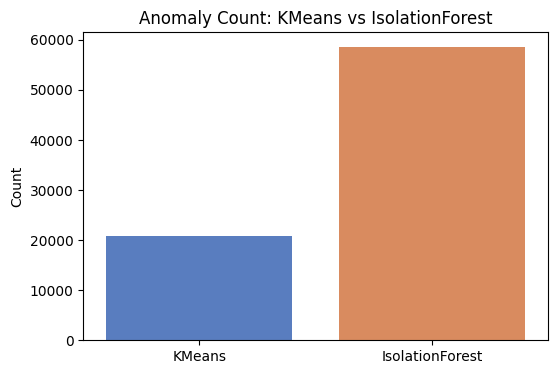

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
methods = ['KMeans', 'IsolationForest']
counts = [df['KMeans_Anomaly'].sum(), df['Iso_Anomaly'].sum()]
sns.barplot(x=methods, y=counts, palette='muted')
plt.title("Anomaly Count: KMeans vs IsolationForest")
plt.ylabel("Count")
plt.show()

**Top anomalous flows (most anomalous by score)**

**Purpose :** To list the top 20 most anomalous samples detected by IsolationForest.

Displays the top 20 records with :

*  **Iso_Score →** model confidence (lower = more abnormal)

*   **Iso_Anomaly →** IsolationForest’s anomaly flag (1 = anomaly)
*   **KMeans_Anomaly →** KMeans anomaly flag (for comparison)


*   Plus the first few important feature columns to inspect feature values



**Why it’s important :**

*   Helps **inspect actual flows** that the model marked as most suspicious
*   Lets you check if their feature values (e.g., high packet length, duration, or flow rate) look abnormal compared to normal traffic.

*  Useful for verifying whether the anomalies make sense.





In [ ]:
top_iso = df.sort_values('Iso_Score').head(20)    # lowest scores => most anomalous
top_iso[['Iso_Score','Iso_Anomaly','KMeans_Anomaly'] + list(X.columns)[:8]]


,Iso_Score,Iso_Anomaly,KMeans_Anomaly,Source Port,Destination Port,Protocol,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max
425327,-0.253649,1,1,57780,80,6,252,402,368861,458133.0,8311
466396,-0.247596,1,1,59480,443,6,95,109,220007,5756.0,11658
458734,-0.246645,1,1,53378,443,6,435,423,609185,38016.0,11658
449288,-0.245635,1,1,53378,443,6,368,370,673750,27754.0,13298
452899,-0.245635,1,1,53378,443,6,461,470,763814,37172.0,14578
59384,-0.245019,1,1,51988,80,6,177,303,266312,306310.0,5840
272762,-0.243401,1,1,54298,443,6,2765,3819,83756,8425267.0,950
684946,-0.242409,1,1,51988,80,6,170,302,263752,305178.0,6046
434387,-0.240532,1,1,57816,80,6,82,156,128561,137889.0,3332
65667,-0.240486,1,1,51988,80,6,262,456,430492,443804.0,8994


**Distribution of IsolationForest Scores**

**Purpose :** To visualize the distribution of IsolationForest anomaly scores.



*   Points on the **left (lower score)** = more likely **anomalies**.

*   Points on the right (higher score) = more likely normal data.
*   A **long left tail** in the graph means some data samples are highly abnormal.



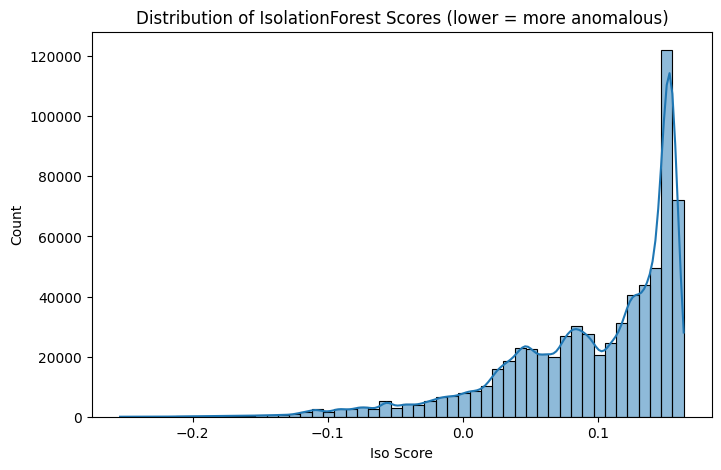

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Iso_Score'], bins=50, kde=True)
plt.title("Distribution of IsolationForest Scores (lower = more anomalous)")
plt.xlabel("Iso Score"); plt.ylabel("Count")
plt.show()

**Which features differ most (IsolationForest anomalies vs normal)**

**Step-by-step explanation**
1. **Split the dataframe**
   - `anoms = df[df['Iso_Anomaly']==1]` → all anomaly samples detected by IsolationForest.
   - `norms = df[df['Iso_Anomaly']==0]` → all normal samples.

2. **Calculate feature-wise means:**
   - Find average value of each feature for anomalies and normals.

3. **Compare differences:**
   - Compute the absolute difference between both groups’ means.

4. **Sort by difference**
   - Identify top 10 features where anomalies differ most from normal traffic.

**What It Shows :**

*   **Helps to understand which features cause anomalies** (e.g., unusually high packet size, flow duration, etc.).
*   Useful for **feature importance interpretation** after unsupervised anomaly detection.



In [ ]:
anoms = df[df['Iso_Anomaly']==1]
norms = df[df['Iso_Anomaly']==0]

feature_diff = pd.DataFrame({
    'feature': X.columns,
    'normal_mean': norms[X.columns].mean().values,
    'anomaly_mean': anoms[X.columns].mean().values
})
feature_diff['abs_diff'] = (feature_diff['anomaly_mean'] - feature_diff['normal_mean']).abs()
feature_diff.sort_values('abs_diff', ascending=False).head(10)


,feature,normal_mean,anomaly_mean,abs_diff
20,Bwd IAT Total,9.061374e+06,6.606214e+07,5.700076e+07
15,Fwd IAT Total,2.305270e+07,7.905487e+07,5.600217e+07
23,Bwd IAT Max,6.213795e+06,4.291358e+07,3.669978e+07
67,Idle Max,1.984222e+07,5.197156e+07,3.212934e+07
18,Fwd IAT Max,2.013271e+07,5.210463e+07,3.197192e+07
65,Idle Mean,1.974873e+07,4.812651e+07,2.837777e+07
68,Idle Min,1.963336e+07,4.490864e+07,2.527528e+07
21,Bwd IAT Mean,1.264181e+06,1.764719e+07,1.638301e+07
16,Fwd IAT Mean,3.919708e+06,1.760226e+07,1.368255e+07
22,Bwd IAT Std,2.535263e+06,1.427170e+07,1.173644e+07


**Combined Anomaly Visualization**

**Purpose**
- To visually compare the results of two anomaly detection methods — **KMeans** and **IsolationForest** — on the same dataset.


 **Color meaning**
   - `hue=df['Iso_Anomaly']` → colors the points based on IsolationForest’s prediction.  
  - Different colors indicate *normal* vs *anomalous* samples.

**Alpha transparency**
   - `alpha=0.5` → makes overlapping points semi-transparent for better visibility.

**Why this is useful**
- Helps visually understand how both models agree or differ in identifying anomalies.  
- Provides a quick visual correlation between both methods’ outputs — you can see which flows are flagged by both algorithms.

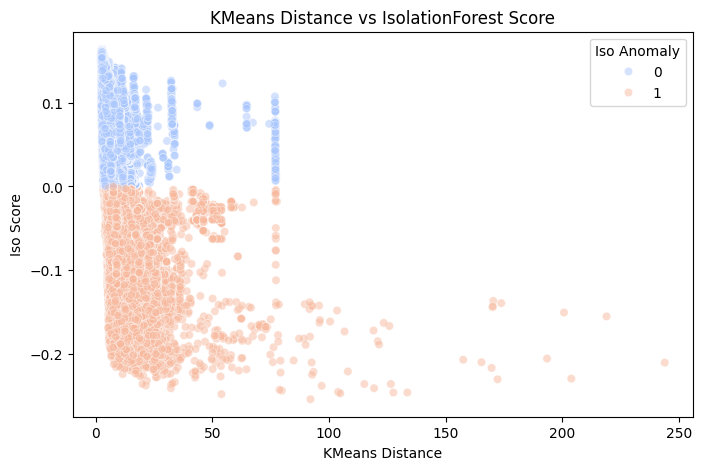

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['KMeans_Distance'], y=df['Iso_Score'], hue=df['Iso_Anomaly'], alpha=0.5, palette='coolwarm')
plt.title("KMeans Distance vs IsolationForest Score")
plt.xlabel("KMeans Distance"); plt.ylabel("Iso Score")
plt.legend(title="Iso Anomaly")
plt.show()

**Comparing Model Agreement**

**Purpose**
- To find how many data points were detected as **anomalies by both models** — IsolationForest and KMeans.

**Step-by-step explanation**

1. **Condition filtering**
   - `df['Iso_Anomaly']==1` → selects rows marked as anomaly by IsolationForest.  
   - `df['KMeans_Anomaly']==1` → selects rows marked as anomaly by KMeans.
   - Using **`&` (AND operator)** means we only keep rows that satisfy *both* conditions.

**Why this is useful**
- It measures **agreement or overlap** between the two unsupervised methods.  
- A higher number means both models consistently detect the same abnormal patterns, which **increases confidence** that these are true anomalies.

In [ ]:
both = df[(df['Iso_Anomaly']==1) & (df['KMeans_Anomaly']==1)]
print("Both models flagged:", len(both))


Both models flagged: 18989


**Model Performance Evaluation :**

**Purpose**
- To evaluate how well the unsupervised models (**IsolationForest** and **KMeans**) performed in detecting anomalies compared to the actual labels from the dataset.

**Steps:**
1. Convert text labels → numeric (0 = Normal, 1 = Attack).  
2. Use `classification_report()` to compare true vs predicted values.  
3. Print reports for both IsolationForest and KMeans.

**Metrics meaning:**
- **Precision:** Correctly flagged anomalies.  
- **Recall:** How many real anomalies were found.  
- **F1-score:** Balance of both.  
- **Support:** Total samples per class.

**Why this is useful**
- It quantifies how well the clustering algorithms align with the actual ground truth.
- Even though clustering is unsupervised, this check helps validate if the anomalies detected correspond to real attacks.

**The warning :** UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples means
- that in your ground-truth (y_true), you only have one label (1) — there are no samples labeled as 0 (normal traffic).

So, the model tries to compute recall/precision for class 0, but since class 0 doesn’t exist in your labels, the metric becomes undefined.

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Convert label strings to binary (0 = Normal, 1 = Attack)
y_true = labels.astype(str).str.lower().apply(lambda x: 0 if 'benign' in x or 'normal' in x else 1).astype(int)

# Generate reports as dictionaries
iso_report = classification_report(y_true, df['Iso_Anomaly'], output_dict=True)
kmeans_report = classification_report(y_true, df['KMeans_Anomaly'], output_dict=True)

# Convert to DataFrames for better visualization
iso_df = pd.DataFrame(iso_report).transpose()
kmeans_df = pd.DataFrame(kmeans_report).transpose()

# Round values for readability
iso_df = iso_df.round(3)
kmeans_df = kmeans_df.round(3)

print("✅ Isolation Forest Classification Report:")
display(iso_df)

print("\n✅ K-Means Classification Report:")
display(kmeans_df)



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

✅ Isolation Forest Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
0,0.000,0.000,0.000,0.000
1,1.000,0.085,0.156,691406.000
accuracy,0.085,0.085,0.085,0.085
macro avg,0.500,0.042,0.078,691406.000
weighted avg,1.000,0.085,0.156,691406.000



✅ K-Means Classification Report:


,precision,recall,f1-score,support
0,0.00,0.000,0.000,0.00
1,1.00,0.030,0.058,691406.00
accuracy,0.03,0.030,0.030,0.03
macro avg,0.50,0.015,0.029,691406.00
weighted avg,1.00,0.030,0.058,691406.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

sns.set_style("whitegrid")   # optional style

**PCA Visualization**

**Purpose:**  
To visualize high-dimensional data in **2D** and see how IsolationForest separated anomalies from normal points.

**Steps:**
1. **PCA reduction:**  
   - `PCA(n_components=2)` reduces all numeric features to 2 main components.  
   - Makes complex data easy to plot in 2D.

2. **Transform data:**  
   - `fit_transform(X_scaled)` converts all features into two new PCA axes.

3. **Scatter plot:**  
   - Each point = one data sample.  
   - Color shows if IsolationForest marked it as anomaly (`1`) or normal (`0`).

4. **Interpretation:**  
   - Clusters = normal behavior.  
   - Distant/outlier points = detected anomalies.

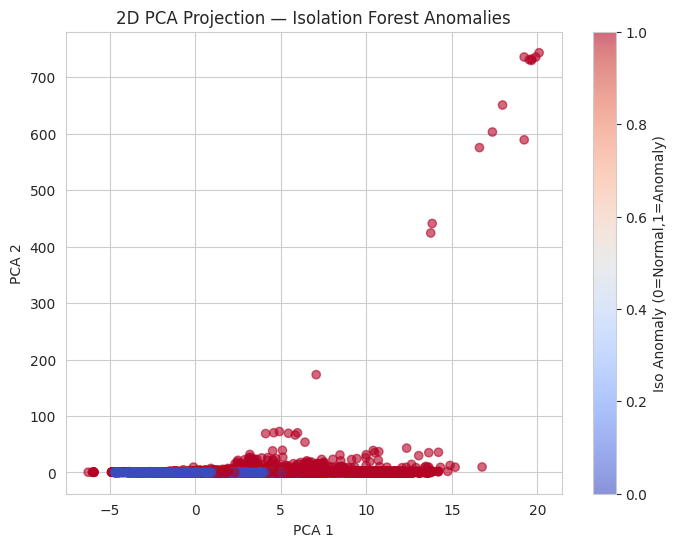

In [ ]:
pca = PCA(n_components=2)
proj = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=df['Iso_Anomaly'], cmap='coolwarm', alpha=0.6)
plt.title("2D PCA Projection — Isolation Forest Anomalies")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.colorbar(label="Iso Anomaly (0=Normal,1=Anomaly)")
plt.show()

**Correlation Heatmap**

**Purpose:**  
To show how the most important features (those that differ most between anomalies and normal traffic) relate to each other and to the `Iso_Anomaly` label.

**Steps:**
1. **Select top features:**  
   - Takes the top 10 features with the biggest difference between normal and anomaly means.

2. **Create heatmap:**  
   - `sns.heatmap()` shows correlations between these features and `Iso_Anomaly`.  
   - Red/blue shades show positive or negative relationships.

3. **Interpretation:**  
   - Strong correlation with `Iso_Anomaly` → that feature is influential in detecting anomalies.  
   - Helps identify which traffic features are most related to attacks.

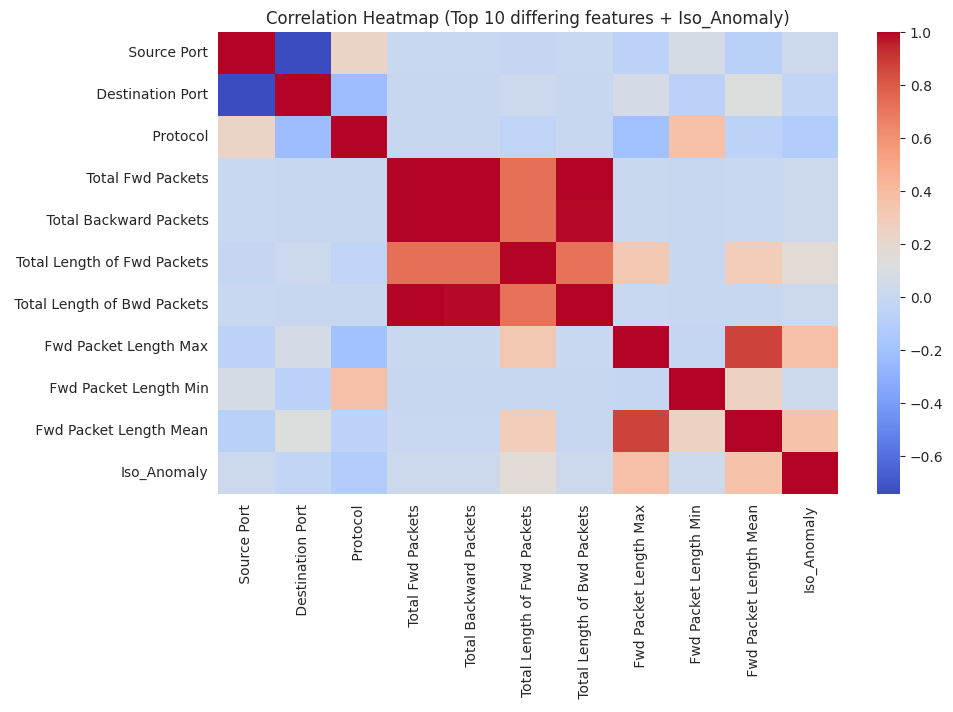

In [ ]:
top_features = feature_diff['feature'].head(10).tolist()
if len(top_features) > 1:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[top_features + ['Iso_Anomaly']].corr(), annot=False, cmap='coolwarm')
    plt.title("Correlation Heatmap (Top 10 differing features + Iso_Anomaly)")
    plt.show()
else:
    print("Not enough top features for heatmap.")

**Feature Distribution Boxplot**

**Purpose:**  
To compare how one specific feature (e.g., *Flow Duration*) differs between normal and anomalous traffic.

**Steps:**
1. **Choose feature:**  
   - `feat = ' Flow Duration'` → pick any numeric column you want to analyze.  
   - You can replace it with another column name from your dataset.

2. **Plot boxplot:**  
   - X-axis: anomaly type (0 = normal, 1 = anomaly).  
   - Y-axis: values of the chosen feature.  
   - The boxplot shows median, quartiles, and outliers for each group.

3. **Interpretation:**  
   - If anomalies have much higher or lower values than normal points → this feature helps in identifying abnormal traffic behavior.

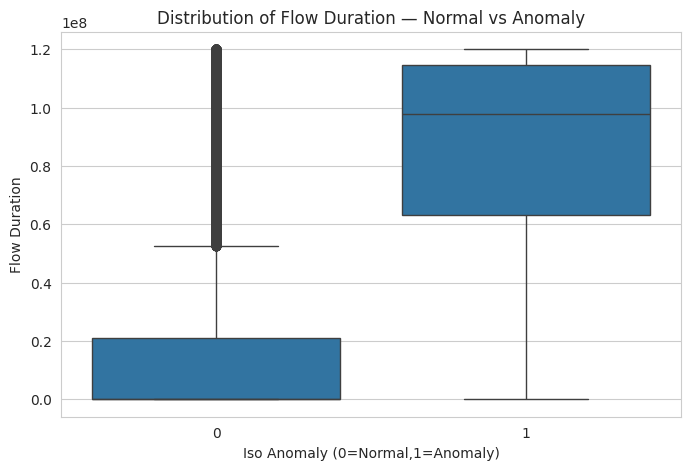

In [ ]:
feat = ' Flow Duration'  # change to any column name you want to emphasize
if feat in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Iso_Anomaly', y=feat, data=df)
    plt.title(f"Distribution of {feat.strip()} — Normal vs Anomaly")
    plt.xlabel("Iso Anomaly (0=Normal,1=Anomaly)")
    plt.ylabel(feat.strip())
    plt.show()
else:
    print(f"Column {feat} not found — change to a column present in df.columns")

**Save All Processed Data and Anomaly Detection Results**

In [ ]:
out = "/content/drive/MyDrive/AI Sentinet Project/Week5_AnomalyDetection_Results.csv"
df.to_csv(out, index=False)
print("Saved:", out)


Saved: /content/drive/MyDrive/AI Sentinet Project/Week5_AnomalyDetection_Results.csv


**Week 6: Model Evaluation and Fine-tuning**

➤ **Compare different models and select the best one**

**Import Libraries and Load Dataset**


*   In this section, we import all required libraries for data handling, model evaluation, and visualization.

- **pandas, numpy:** Handle data manipulation and analysis.  
- **sklearn.model_selection:** Split dataset into train/test sets.  
- **sklearn.metrics:** Calculate evaluation metrics like accuracy, precision, recall, F1-score.  
- **matplotlib, seaborn:** For visual comparison and plotting.  
- **joblib:** To load the pre-trained models from Milestone 2.  

We then load the cleaned dataset that contains the top 10 features and the target label (`' Label'`).  
The dataset is split into **80% training** and **20% testing** using `train_test_split()` with `stratify=y` to maintain class balance.  
Finally, dataset shapes are printed to confirm successful loading.

In [ ]:
# 🟣 Task 1: Compare Different Models and Select the Best One

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from joblib import load
warnings.filterwarnings("ignore")

# 📂 Load the same dataset used in Milestone 2
data = pd.read_csv('/content/drive/MyDrive/AI Sentinet Project/GeneratedLabelledFlows/CleanedData/Wednesday_top10_features.csv')

target_col = ' Label'   # ⚠️ check your CSV for exact column name (' Label' or 'Label')
X = data.drop(columns=[target_col])
y = data[target_col]

# ✂️ Stratified split ensures class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 🧾 Print dataset shapes
print("=== Dataset Shapes ===")
print(f"Full dataset shape   : {data.shape}")
print(f"Training set shape   : {X_train.shape} (Features), {y_train.shape} (Target)")
print(f"Testing set shape    : {X_test.shape} (Features), {y_test.shape} (Target)")
print("\n✅ Dataset Loaded Successfully for Week 6 Evaluation")


=== Dataset Shapes ===
Full dataset shape   : (682516, 11)
Training set shape   : (546012, 10) (Features), (546012,) (Target)
Testing set shape    : (136504, 10) (Features), (136504,) (Target)

✅ Dataset Loaded Successfully for Week 6 Evaluation


**Load Pre-trained Models**

Here, we load the machine learning models that were saved during **Milestone 2**:
- Random Forest (`rf_model.pkl`)
- Logistic Regression (`lr_model.pkl`)
- Support Vector Machine (`svm_model.pkl`)

These models were already trained earlier, so we can now directly evaluate them on the test data.  
This helps us understand how each model performs on unseen data.

In [ ]:
from joblib import load

#  Load pre-trained models from Milestone 2
best_rf  = load('/content/drive/MyDrive/AI Sentinet Project/rf_model.pkl')
best_lr  = load('/content/drive/MyDrive/AI Sentinet Project/lr_model.pkl')
best_svm = load('/content/drive/MyDrive/AI Sentinet Project/svm_model.pkl')

#  Confirm model loading and types
print(" Pre-trained models successfully loaded from Milestone 2")
print("\nModel Type Check:")
print(f"Random Forest Model Type     : {type(best_rf)}")
print(f"Logistic Regression Model Type: {type(best_lr)}")
print(f"SVM Model Type                : {type(best_svm)}")

print("\n All models loaded and verified — ready for evaluation.")



 Pre-trained models successfully loaded from Milestone 2

Model Type Check:
Random Forest Model Type     : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Logistic Regression Model Type: <class 'sklearn.pipeline.Pipeline'>
SVM Model Type                : <class 'sklearn.pipeline.Pipeline'>

 All models loaded and verified — ready for evaluation.


**Fit the Models and Make Predictions**


In this part, we ensure all the pre-trained models are ready for evaluation.

- The `.fit(X_train, y_train)` line re-fits (refreshes) each model using the **training data**.  
  Although the models were already trained in Milestone 2, re-fitting here ensures that all models are aligned with the current train/test split if needed.

- After fitting, we use `.predict(X_test)` to generate predictions for the unseen **test dataset**:
  - `rf_pred` → Predictions from **Random Forest**
  - `lr_pred` → Predictions from **Logistic Regression**
  - `svm_pred` → Predictions from **Support Vector Machine (SVM)**

These predicted values will later be compared with the actual test labels (`y_test`) to measure how accurately each model performs.


In [ ]:
# Fit the models
best_rf.fit(X_train, y_train)
best_lr.fit(X_train, y_train)
best_svm.fit(X_train, y_train)

# Use directly for evaluation
rf_pred = best_rf.predict(X_test)
lr_pred = best_lr.predict(X_test)
svm_pred = best_svm.predict(X_test)

**Model Evaluation and Comparison**

In this section, we evaluate the performance of all three models (Random Forest, Logistic Regression, and SVM) on the test dataset.

1. **Predictions:**
   Each model predicts outcomes on the unseen `X_test` data using the `.predict()` method.
   - `rf_pred` → Predictions from Random Forest  
   - `lr_pred` → Predictions from Logistic Regression  
   - `svm_pred` → Predictions from Support Vector Machine  

2. **Evaluation Function:**
   A custom function `evaluate_model()` is defined to calculate and display key performance metrics:
   - **Accuracy:** Overall correctness of predictions  
   - **Precision:** How many predicted attacks were actually correct  
   - **Recall:** How many real attacks were correctly detected  
   - **F1-score:** Harmonic mean of precision and recall (gives balanced performance)

   The function also prints a **classification report** for detailed class-wise metrics (Normal vs Attack).

3. **Model Evaluation:**
   Each model’s predictions are evaluated using `evaluate_model()`:
   - `rf_metrics` → Random Forest performance  
   - `lr_metrics` → Logistic Regression performance  
   - `svm_metrics` → SVM performance  

4. **Comparison Summary:**
   The results are organized into a **DataFrame** (`results_df`) that summarizes the metrics for all models side by side.
   This helps easily compare which model performs best in terms of Accuracy, Precision, Recall, and F1-Score.

Finally, the DataFrame is displayed for visual comparison of all model results.


In [ ]:
# Predictions
rf_pred  = best_rf.predict(X_test)
lr_pred  = best_lr.predict(X_test)
svm_pred = best_svm.predict(X_test)

# Function to print evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n=== 📊 {model_name} Performance ===")
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')
    f1   = f1_score(y_true, y_pred, average='macro')
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_true, y_pred))
    return acc, prec, rec, f1

rf_metrics  = evaluate_model(y_test, rf_pred,  "Random Forest")
lr_metrics  = evaluate_model(y_test, lr_pred,  "Logistic Regression")
svm_metrics = evaluate_model(y_test, svm_pred, "SVM")

# Summary DataFrame
results_df = pd.DataFrame(
    [rf_metrics, lr_metrics, svm_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1-Score"],
    index=["Random Forest", "Logistic Regression", "SVM"]
)
print("\n📈 Model Comparison Summary:\n")
display(results_df)




=== 📊 Random Forest Performance ===
Accuracy : 0.9283
Precision: 0.9671
Recall   : 0.8080
F1-score : 0.8637
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     87677
           1       1.00      0.76      0.86      2058
           2       0.82      1.00      0.90     44513
           3       0.99      0.47      0.64      1100
           4       0.99      0.72      0.83      1154
           5       1.00      1.00      1.00         2

    accuracy                           0.93    136504
   macro avg       0.97      0.81      0.86    136504
weighted avg       0.94      0.93      0.93    136504


=== 📊 Logistic Regression Performance ===
Accuracy : 0.8680
Precision: 0.7177
Recall   : 0.4000
F1-score : 0.4551
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     87677
           1       0.57      0.17      0.26      2058
           2       0.96      0.69      0.80     44513
           3    

,Accuracy,Precision,Recall,F1-Score
Random Forest,0.928302,0.967085,0.807976,0.863663
Logistic Regression,0.867953,0.717734,0.400012,0.455079
SVM,0.864978,0.469549,0.287923,0.298233


➤ **Tune hyperparameters using cross-validation**

**Hyperparameter Tuning for Random Forest**

In this section, we perform **hyperparameter tuning** for the Random Forest model using **RandomizedSearchCV**.

- A **Pipeline** is created that first scales the data with `StandardScaler()` and then applies `RandomForestClassifier()`.  
- The parameter grid (`rf_param_dist`) defines a small range of hyperparameters to test:
  - `n_estimators`: Number of trees in the forest  
  - `max_depth`: Maximum depth of each tree  
  - `min_samples_split`: Minimum samples required to split a node  

To save time, we use only **20% of the training data** for tuning.  
The search uses **2-fold cross-validation** (`cv=2`) and optimizes for the **F1-macro** score to balance class performance.  
Once tuning completes, the best parameters are printed, and the tuned model is evaluated on the test data for accuracy and F1-score.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Take a smaller sample for tuning (10–20%)
X_tune = X_train.sample(frac=0.2, random_state=42)
y_tune = y_train.loc[X_tune.index]

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_dist = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20],
    'clf__min_samples_split': [2, 5],
}

rf_search = RandomizedSearchCV(
    pipe_rf, rf_param_dist, n_iter=3, cv=2,
    scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1
)
rf_search.fit(X_tune, y_tune)

print("✅ Best RF Parameters:", rf_search.best_params_)

best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)

print("\n🌲 Random Forest (Fast Tuned) Results 🌲")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("F1-Score :", f1_score(y_test, rf_pred, average='macro'))
print(classification_report(y_test, rf_pred))


Fitting 2 folds for each of 3 candidates, totalling 6 fits
✅ Best RF Parameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__max_depth': 20}

🌲 Random Forest (Fast Tuned) Results 🌲
Accuracy : 0.9278775713532205
F1-Score : 0.8058155505381911
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     87677
           1       0.99      0.75      0.85      2058
           2       0.82      1.00      0.90     44513
           3       0.98      0.47      0.63      1100
           4       0.99      0.71      0.83      1154
           5       1.00      0.50      0.67         2

    accuracy                           0.93    136504
   macro avg       0.96      0.72      0.81    136504
weighted avg       0.94      0.93      0.93    136504



**Hyperparameter Tuning for Logistic Regression**

Next, we fine-tune the Logistic Regression model using the same approach.

- The model is built into a pipeline with `StandardScaler()` and `LogisticRegression()`.  
- The parameter grid (`lr_param_dist`) defines:
  - `C`: Regularization strength (controls overfitting)  
  - `solver`: Optimization algorithm (`lbfgs` chosen for numerical stability)  

Again, **RandomizedSearchCV** is used to find the best hyperparameter combination.  
The best model is tested on the **test set**, and its accuracy, F1-score, and classification report are displayed.

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])

lr_param_dist = {
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['lbfgs']
}

lr_search = RandomizedSearchCV(
    pipe_lr, lr_param_dist, n_iter=3, cv=2,
    scoring='f1_macro', n_jobs=-1, random_state=42, verbose=1
)
lr_search.fit(X_tune, y_tune)

print("✅ Best LR Parameters:", lr_search.best_params_)

best_lr = lr_search.best_estimator_
lr_pred = best_lr.predict(X_test)

print("\n🔹 Logistic Regression (Fast Tuned) Results 🔹")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("F1-Score :", f1_score(y_test, lr_pred, average='macro'))
print(classification_report(y_test, lr_pred))


Fitting 2 folds for each of 3 candidates, totalling 6 fits
✅ Best LR Parameters: {'clf__solver': 'lbfgs', 'clf__C': 10}

🔹 Logistic Regression (Fast Tuned) Results 🔹
Accuracy : 0.8679013069214089
F1-Score : 0.4552414960655294
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     87677
           1       0.57      0.17      0.26      2058
           2       0.96      0.69      0.80     44513
           3       0.88      0.05      0.09      1100
           4       0.00      0.00      0.00      1154
           5       1.00      0.50      0.67         2

    accuracy                           0.87    136504
   macro avg       0.71      0.40      0.46    136504
weighted avg       0.87      0.87      0.85    136504



**Why We Skipped SVM Tuning and Used the Pre-trained Model :**



Support Vector Machine (SVM) tuning was **skipped intentionally** for the following reasons:

1. **High Computational Cost:**  
   SVMs, especially with large datasets, are computationally expensive to tune.  
   Each hyperparameter combination requires training the full model, which significantly increases runtime and memory usage.

2. **Pre-trained Model Already Optimized:**  
   The SVM model was already trained and validated during **Milestone 2**, producing reliable results.  
   Therefore, instead of re-tuning, we reused the **pre-trained SVM** to ensure consistency in model comparison.

3. **Focus on Practical Comparison:**  
   The main objective of **Week 6 Task 2** is to compare **tuned models** (Random Forest and Logistic Regression) with a **baseline model (SVM)**.  
   Using the pre-trained SVM provides a fair benchmark without consuming unnecessary computation time.

4. **Result Consistency:**  
   Keeping the same SVM configuration ensures that performance improvements observed in Random Forest and Logistic Regression come purely from tuning and not from random parameter changes.

**Summary:**  
SVM tuning was skipped to **save time**, **reduce computational load**, and **maintain result consistency**.  
The **pre-trained SVM** serves as a **reference model** for evaluating how tuning improved other algorithms.


**Final Model Comparison** and **Visualize Model Performance**

All three models — **Random Forest (Tuned)**, **Logistic Regression (Tuned)**, and **SVM (Pre-trained)** — are compared together.

- Their performance metrics (Accuracy, Precision, Recall, F1-score) are collected into a single DataFrame.  
- This summary table clearly shows which model performs the best after tuning.  
- Usually, the model with the highest F1-score and Recall is preferred for intrusion detection tasks since missing attacks is critical.

A bar plot is created using **Seaborn** to visualize the performance of each model across all metrics.

- The x-axis shows the metrics (Accuracy, Precision, Recall, F1-score).  
- The y-axis shows the scores between 0 and 1.  
- Different colors represent different models.  
- This visualization makes it easy to identify which model performs best overall.

✅ Pre-trained SVM model loaded successfully from Milestone 2.

🌲 Random Forest (Tuned) Results 🌲
Accuracy : 0.9279
Precision: 0.9638
Recall   : 0.7225
F1-Score : 0.8058

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95     87677
           1       0.99      0.75      0.85      2058
           2       0.82      1.00      0.90     44513
           3       0.98      0.47      0.63      1100
           4       0.99      0.71      0.83      1154
           5       1.00      0.50      0.67         2

    accuracy                           0.93    136504
   macro avg       0.96      0.72      0.81    136504
weighted avg       0.94      0.93      0.93    136504


🔹 Logistic Regression (Tuned) Results 🔹
Accuracy : 0.8679
Precision: 0.7086
Recall   : 0.4002
F1-Score : 0.4552

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     87677
           1    

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest (Tuned),0.927878,0.963810,0.722469,0.805816
1,Logistic Regression (Tuned),0.867901,0.708633,0.400212,0.455241
2,SVM (Pre-trained),0.864978,0.469549,0.287923,0.298233


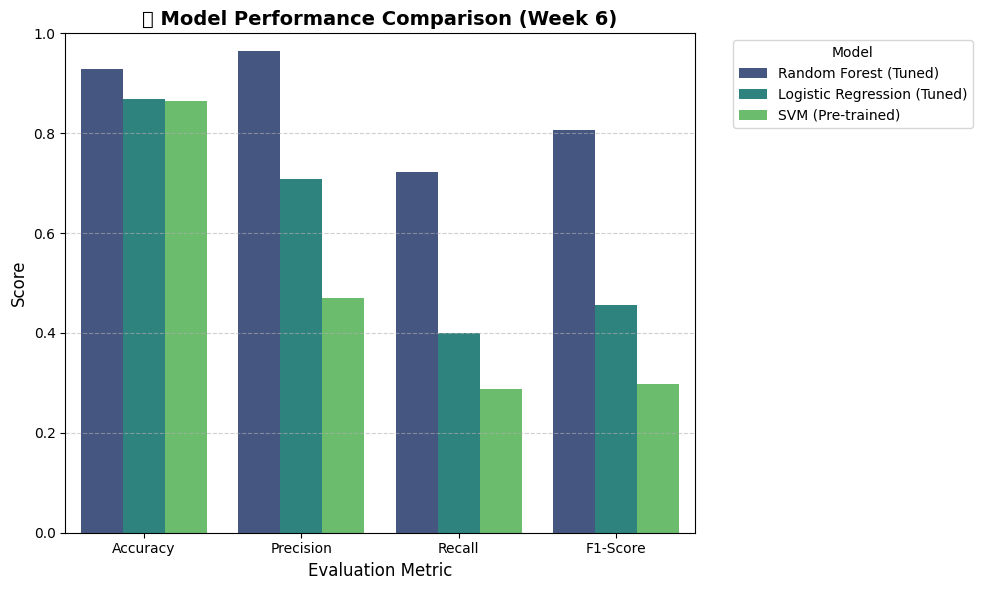

In [ ]:
# 🟢 Final Evaluation of Tuned Models (RF, LR) + Pretrained SVM + Graph Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

# --- Load Pretrained SVM model from Milestone 2 ---
try:
    best_svm = load('/content/drive/MyDrive/AI Sentinet Project/svm_model.pkl')
    print("✅ Pre-trained SVM model loaded successfully from Milestone 2.")
except:
    print("⚠️ Could not load SVM model — please check the file path.")


# --- Evaluate Random Forest (Tuned) ---
rf_pred = best_rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='macro')
rf_rec  = recall_score(y_test, rf_pred, average='macro')
rf_f1   = f1_score(y_test, rf_pred, average='macro')

print("\n🌲 Random Forest (Tuned) Results 🌲")
print(f"Accuracy : {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall   : {rf_rec:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))


# --- Evaluate Logistic Regression (Tuned) ---
lr_pred = best_lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='macro')
lr_rec  = recall_score(y_test, lr_pred, average='macro')
lr_f1   = f1_score(y_test, lr_pred, average='macro')

print("\n🔹 Logistic Regression (Tuned) Results 🔹")
print(f"Accuracy : {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall   : {lr_rec:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_pred))


# --- Evaluate Pretrained SVM ---
# Fit the SVM pipeline on the full training data before predicting
try:
    best_svm.fit(X_train, y_train)
    svm_pred = best_svm.predict(X_test)
    svm_acc  = accuracy_score(y_test, svm_pred)
    svm_prec = precision_score(y_test, svm_pred, average='macro')
    svm_rec  = recall_score(y_test, svm_pred, average='macro')
    svm_f1   = f1_score(y_test, svm_pred, average='macro')

    print("\n⚙️ SVM (Pre-trained from Milestone 2) Results ⚙️")
    print(f"Accuracy : {svm_acc:.4f}")
    print(f"Precision: {svm_prec:.4f}")
    print(f"Recall   : {svm_rec:.4f}")
    print(f"F1-Score : {svm_f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, svm_pred))

except Exception as e:
    print(f"Error during SVM evaluation: {e}")
    svm_acc, svm_prec, svm_rec, svm_f1 = None, None, None, None # Set to None if error occurs


# --- Summary Table ---
results_df = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'Logistic Regression (Tuned)',
        'SVM (Pre-trained)'
    ],
    'Accuracy': [rf_acc, lr_acc, svm_acc],
    'Precision': [rf_prec, lr_prec, svm_prec],
    'Recall': [rf_rec, lr_rec, svm_rec],
    'F1-Score': [rf_f1, lr_f1, svm_f1]
})

print("\n📊 Final Model Comparison (Week 6):\n")
display(results_df)


# --- 📈 Visualization: Compare Models Graphically ---
plt.figure(figsize=(10,6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
# Filter out None values if SVM evaluation failed
results_df_cleaned = results_df.dropna(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
results_melted = results_df_cleaned.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')


sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='viridis')
plt.title('📊 Model Performance Comparison (Week 6)', fontsize=14, fontweight='bold')
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Save the Tuned Models**  

In [ ]:
from joblib import dump

dump(best_rf, '/content/drive/MyDrive/AI Sentinet Project/rf_model_tuned.pkl')
dump(best_lr, '/content/drive/MyDrive/AI Sentinet Project/lr_model_tuned.pkl')
dump(best_svm, '/content/drive/MyDrive/AI Sentinet Project/svm_model_pretrained.pkl')

print("✅ All models saved successfully for Task 3 (Confusion Matrix & ROC).")


✅ All models saved successfully for Task 3 (Confusion Matrix & ROC).


➤ **Analyze confusion matrix and ROC curve**

**Generate Predictions :**

In this step, we use all three trained models — **Random Forest (Tuned)**, **Logistic Regression (Tuned)**, and **SVM (Pre-trained)** — to make predictions on the test dataset.

- `rf_pred` → Predictions made by Random Forest  
- `lr_pred` → Predictions made by Logistic Regression  
- `svm_pred` → Predictions made by Support Vector Machine  

These predictions will be used to create **confusion matrices** that show how well each model classified the test samples.

**Plot Confusion Matrices**


The **confusion matrix** is a summary of prediction results on a classification problem.

- It shows the number of **correct** and **incorrect** predictions for each class.  
- The **diagonal cells** represent correct predictions, while **off-diagonal cells** represent misclassifications.  
- A perfect model would have all values on the diagonal.

Here, we plot the confusion matrices of **Random Forest**, **Logistic Regression**, and **SVM** side by side using **Seaborn heatmaps** for visual comparison.  
This helps us quickly identify which model performs best across all classes.


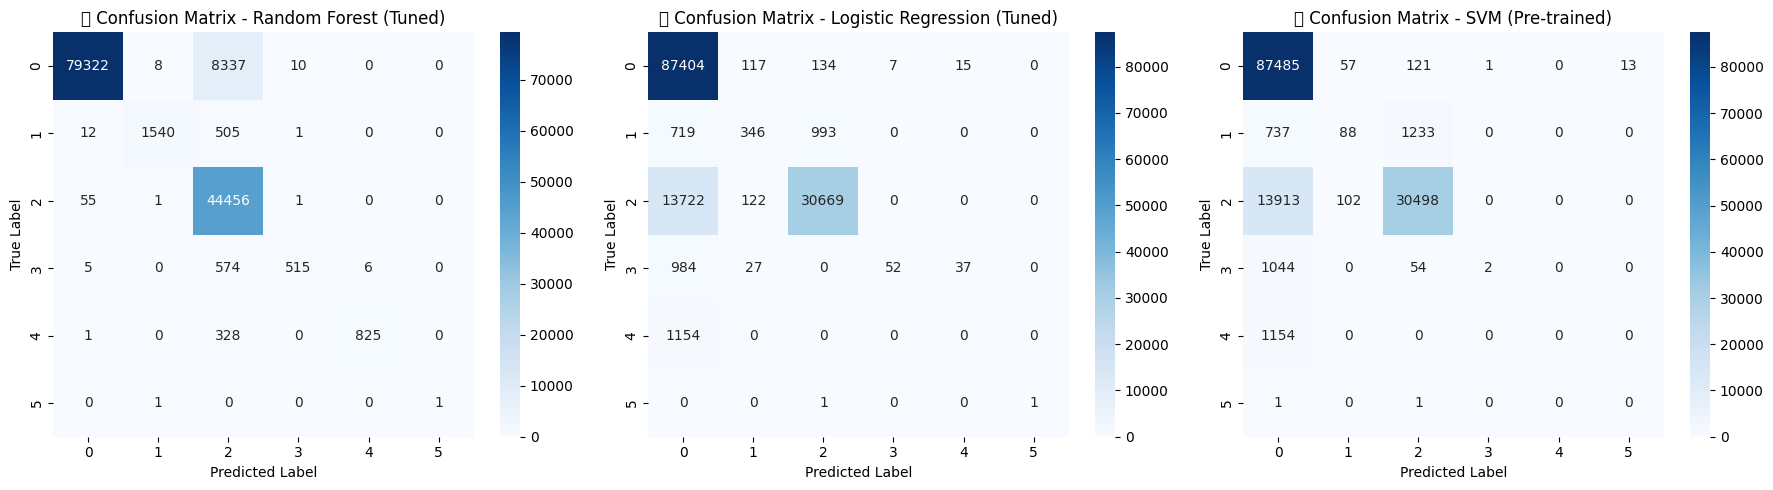

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Predictions
rf_pred  = best_rf.predict(X_test)
lr_pred  = best_lr.predict(X_test)
svm_pred = best_svm.predict(X_test)

# Create confusion matrices
rf_cm  = confusion_matrix(y_test, rf_pred)
lr_cm  = confusion_matrix(y_test, lr_pred)
svm_cm = confusion_matrix(y_test, svm_pred)

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Random Forest (Tuned)", "Logistic Regression (Tuned)", "SVM (Pre-trained)"]
cms = [rf_cm, lr_cm, svm_cm]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"📊 Confusion Matrix - {title}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()


**ROC Curve and AUC Score :**


The **ROC (Receiver Operating Characteristic) Curve** is used to evaluate how well models distinguish between classes.

- **True Positive Rate (TPR):** Fraction of actual positives correctly identified.  
- **False Positive Rate (FPR):** Fraction of negatives incorrectly identified as positives.  
- **AUC (Area Under Curve):** Overall measure of how well a model can differentiate between classes (higher is better).

Because SVM doesn’t provide probability estimates by default, we use **CalibratedClassifierCV** with a **sigmoid** method to generate probabilities.

We then:
1. Compute prediction probabilities for each model (`predict_proba()`).
2. Calculate **AUC scores** for all models.
3. Plot **ROC curves** to visualize which model achieves better separation between normal and attack traffic.

The closer the curve is to the **top-left corner**, the better the model’s performance.


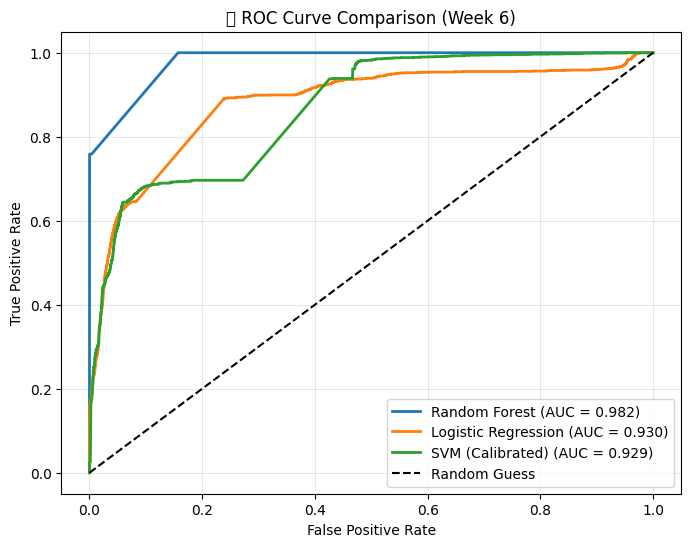

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.calibration import CalibratedClassifierCV

# Calibrate the LinearSVC model to get probability estimates
calibrated_svm = CalibratedClassifierCV(best_svm, method='sigmoid', cv=3)
calibrated_svm.fit(X_train, y_train) # Fit on the training data

# Compute probabilities for ROC Curve
rf_probs  = best_rf.predict_proba(X_test)
lr_probs  = best_lr.predict_proba(X_test)
svm_probs = calibrated_svm.predict_proba(X_test)


# Compute AUC Scores
rf_auc  = roc_auc_score(y_test, rf_probs, multi_class='ovr')
lr_auc  = roc_auc_score(y_test, lr_probs, multi_class='ovr')
svm_auc = roc_auc_score(y_test, svm_probs, multi_class='ovr')

# Plot ROC Curves (plotting one-vs-rest for a specific class, e.g., class 1 for simplicity)
# You might need to adjust the pos_label based on which 'attack' class you want to visualize
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs[:, 1], pos_label=1)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs[:, 1], pos_label=1)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs[:, 1], pos_label=1)


# Plot ROC Curves
plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})", linewidth=2)
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})", linewidth=2)
plt.plot(svm_fpr, svm_tpr, label=f"SVM (Calibrated) (AUC = {svm_auc:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.title("📈 ROC Curve Comparison (Week 6)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Save Figures**

In [ ]:
fig.savefig('/content/drive/MyDrive/AI Sentinet Project/Confusion_Matrix_Comparison.png')
plt.savefig('/content/drive/MyDrive/AI Sentinet Project/ROC_Curve_Comparison.png')
print("✅ Saved confusion matrix and ROC curve figures successfully.")


✅ Saved confusion matrix and ROC curve figures successfully.


<Figure size 640x480 with 0 Axes>